# 01 — Data Exploration

Plot processed GeoTIFF tiles alongside their ground-truth YOLO OBB labels.
All logic is imported from ; this notebook contains no business logic.

In [1]:
# ── Standard library ──────────────────────────────────────────────────────
import sys
from pathlib import Path

# Add project root to path so  is importable when running from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

# ── Third-party ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import rasterio
from matplotlib.collections import PatchCollection

# ── Project ───────────────────────────────────────────────────────────────
from src.vessels_detect.utils.config import load_config

from src.vessels_detect.utils.config import load_config
from src.vessels_detect.evaluation.metrics import (

    build_size_dataframe,
    parse_label_file,
    count_split_labels

)

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("Imports OK.")

Imports OK.


## 1. Configuration

Change the paths below to match your environment.

In [2]:
cfg = load_config("../configs/preprocessing.yaml")
PROCESSED = Path("../data/dataset")

# --- Configuration ---
LABELS_ROOT = PROCESSED / "labels"
IMAGES_ROOT = PROCESSED / "images"   

SPLIT = ["train", "val", "test"]

# Class names
import yaml
with open("../data/dataset.yaml") as f:
    _ds = yaml.safe_load(f)

CLASS_NAMES = _ds["names"]

print(f"Images root : {IMAGES_ROOT}")
print(f"Labels root : {LABELS_ROOT}")
print(f"Classes     : {CLASS_NAMES}")

Images root : ../data/dataset/images
Labels root : ../data/dataset/labels
Classes     : {0: 'Pirogue', 1: 'Double_hulled_Pirogue', 2: 'Small_Motorboat', 3: 'Medium_Motorboat', 4: 'Large_Motorboat', 5: 'Sailing_Boat'}


## 2. Dataset Statistics

Per-class annotation counts across all splits.

In [3]:
from src.vessels_detect.evaluation.metrics import build_distribution_dataframe

df_dist = build_distribution_dataframe(
    LABELS_ROOT,
    SPLIT,
    class_names=CLASS_NAMES,
)

print("Object counts per class and split:")
display(df_dist)

classes = list(CLASS_NAMES.values())
x, width = np.arange(len(classes)), 0.25



Object counts per class and split:


,Class,Train,Val,Test,Total
0,Pirogue,606,160,99,865
1,Double_hulled_Pirogue,530,69,119,718
2,Small_Motorboat,262,37,30,329
3,Medium_Motorboat,100,16,0,116
4,Large_Motorboat,23,0,0,23
5,Sailing_Boat,88,6,6,100


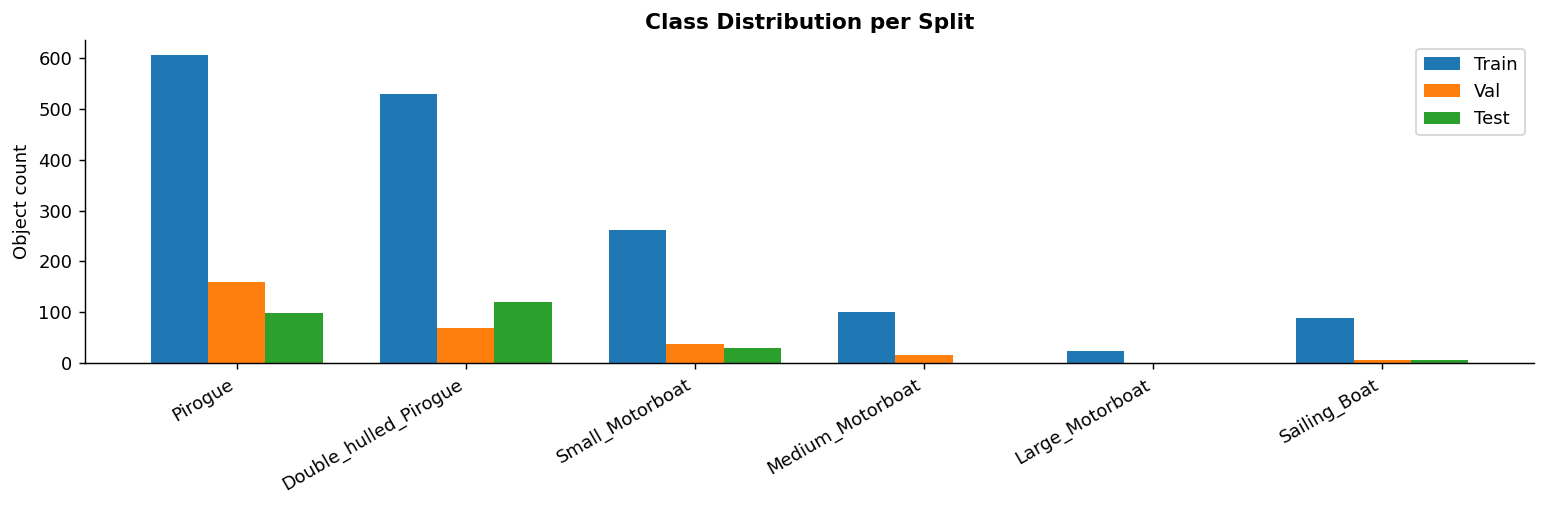

In [4]:
# Bar chart
splits   = SPLIT
classes  = list(CLASS_NAMES.values())
x        = np.arange(len(classes))
width    = 0.25

fig, ax = plt.subplots(figsize=(12, 4))
for i, split in enumerate(splits):
    vals = df_dist[split.capitalize()].values if split.capitalize() in df_dist else [0]*len(classes)
    ax.bar(x + i * width, vals, width, label=split.capitalize())

ax.set_xticks(x + width)
ax.set_xticklabels(classes, rotation=30, ha="right")
ax.set_ylabel("Object count")
ax.set_title("Class Distribution per Split", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 4. OBB Geometric Statistics

Long side, short side, area, and aspect ratio per class across all splits.

,Class ID,Class,Count,Long mean (px),Long std,Short mean (px),Short std,Area mean (px²),Aspect ratio
0,0,Pirogue,865,92.59,32.23,27.54,11.15,2804.86,3.53
1,1,Double_hulled_Pirogue,718,146.52,52.29,80.64,31.19,13173.71,1.88
2,2,Small_Motorboat,329,148.27,47.81,53.37,16.73,8488.93,2.86
3,3,Medium_Motorboat,116,465.24,234.73,113.02,53.13,63530.76,4.16
4,4,Large_Motorboat,23,1097.64,830.74,279.29,225.50,486410.03,4.11
5,5,Sailing_Boat,100,252.84,74.03,74.39,25.47,18978.21,3.61


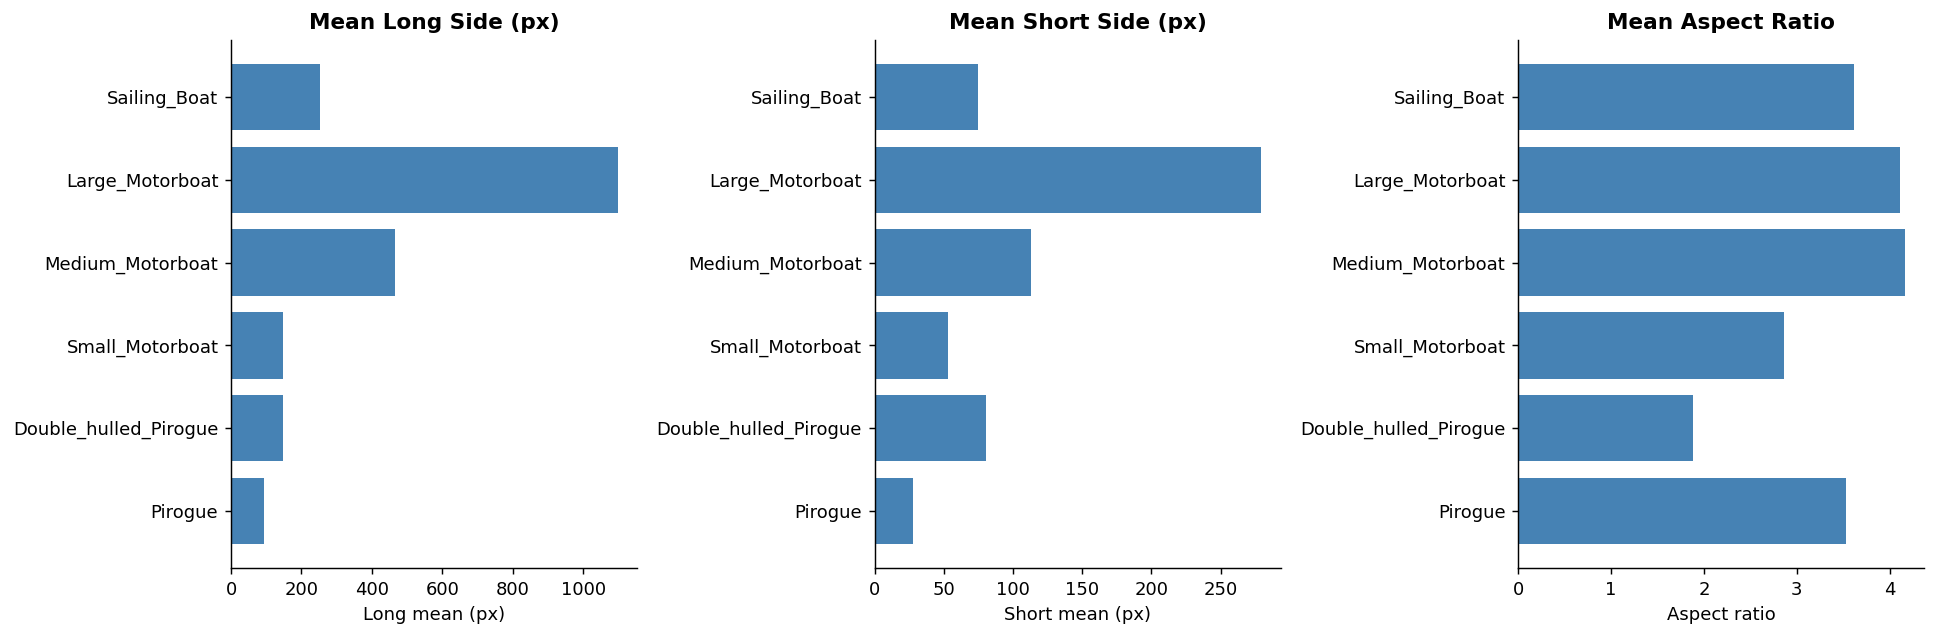

In [5]:
df_sizes = build_size_dataframe(
    LABELS_ROOT,
    IMAGES_ROOT,   # 🔥 NEW
    SPLIT,
    CLASS_NAMES
)

display(df_sizes)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, title in zip(
    axes,
    ["Long mean (px)", "Short mean (px)", "Aspect ratio"],
    ["Mean Long Side (px)", "Mean Short Side (px)", "Mean Aspect Ratio"],
):
    ax.barh(df_sizes["Class"], df_sizes[col], color="steelblue")
    ax.set_xlabel(col); ax.set_title(title, fontweight="bold")

plt.tight_layout(); plt.show()